In [1]:
import pandas as pd
import json
import plotly.express as px
import numpy as np
import seaborn as sns

In [2]:
with open('./user_course_info_cleaned.json', 'r') as file:
    user_course_info = json.load(file)

df_user_course_info = pd.DataFrame(user_course_info)

In [3]:
with open('./teacher_stats_cleaned.json', 'r') as file:
    teacher_stats = json.load(file)

df_teacher_stats = pd.DataFrame(teacher_stats)

In [4]:
with open('./pro_course_cleaned.json', 'r') as file:
    pro_course = json.load(file)

df_pro_course = pd.DataFrame(pro_course)

In [5]:
with open('./price_list_cleaned.json', 'r') as file:
    price_list = json.load(file)

df_price_list = pd.DataFrame(price_list)

In [6]:
with open('./also_speaks_cleaned.json', 'r') as file:
    also_speaks = json.load(file)

df_also_speaks = pd.DataFrame(also_speaks)

In [7]:
with open('./also_speaks_reference.json', 'r') as file:
    also_speaks_reference = json.load(file)

df_also_speaks_reference = pd.DataFrame(also_speaks_reference)

Price Prediction Model Functions

In [114]:
def tutor_pro(tutor):
    if tutor == True:
        df_tutors = df_user_course_info[(df_user_course_info['is_tutor'] == 1) & (df_user_course_info['is_pro']  == 0)]
        return df_tutors[['user_id', 'trial_session_count', 'trial_price']]
    else:
        df_pros_1 = df_user_course_info[(df_user_course_info['is_tutor'] == 1) & (df_user_course_info['is_pro']  == 1)]
        df_pros_2 = df_user_course_info[(df_user_course_info['is_tutor'] == 0) & (df_user_course_info['is_pro']  == 1)]
        df_pros_combined = pd.concat([df_pros_1, df_pros_2], ignore_index=True)
        df_pros_combined = df_pros_combined[['user_id', 'trial_session_count', 'trial_price']]
        return df_pros_combined
        
        
tutor_pro(True)

,user_id,trial_session_count,trial_price
0,55502,97,1000
3,132815,0,750
6,249152,70,800
11,355886,142,500
12,368484,91,1000
...,...,...,...
10465,32167939,3,1000
10466,32168520,0,500
10467,32169200,0,1400
10468,32169731,0,600


In [115]:
def teacher_id_language(language):
    df_teachers_id = df_pro_course[df_pro_course['language'] == language].groupby(['teacher_id', 'language']).count()
    df_teachers_id = df_teachers_id.reset_index()
    df_teachers_id = df_teachers_id[['teacher_id']]
    return df_teachers_id

teacher_id_language('chinese')

,teacher_id
0,55502
1,113638
2,114708
3,259649
4,436016
...,...
993,31845535
994,31847889
995,31913484
996,31915782


In [116]:
def pro_course_language(language):
    df_pro_course_target = df_pro_course[df_pro_course['language'] == language]
    return df_pro_course_target

pro_course_language('english')

,id,teacher_id,language,title,session_price,student_count,session_count,has_package
0,375,436016,english,English courses新概念英语（1）,1400,15,106,0
4,4042,463477,english,One-on-One tutoring: English,3200,95,1504,1
6,5779,502096,english,One-on-One tutoring: English,2300,84,876,1
17,10048,596847,english,English language instruction,2600,147,2881,1
21,10779,483024,english,English Pronunciation & Intonation,6500,49,90,1
...,...,...,...,...,...,...,...,...
39014,290713,18491956,english,IELTS Preparation Course,800,0,0,1
39015,290714,18491956,english,"Medical, Health & Fitness English",800,0,0,1
39017,290721,5846271,english,"Beginner English (for FR, ES, PT, ZH speakers)",2200,0,0,1
39019,290736,19100180,english,English Language Topics Lesson,2300,0,0,1


In [120]:
def language_tutor_pro(language, tutor):        
    df_tutor_pro = tutor_pro(tutor)
    df_language = pro_course_language(language)
    df_merged = pd.merge(df_tutor_pro, df_language, left_on='user_id', right_on='teacher_id', how='inner')
    # df_merged = df_merged[['user_id', 'trial_session_count', 'trial_price', 'student_count', 'session_count', 'has_package', 'session_price']]
    df_merged = df_merged[['trial_session_count', 'trial_price', 'student_count', 'session_count', 'has_package', 'session_price']]
    return df_merged

language_tutor_pro('french', True)

,trial_session_count,trial_price,student_count,session_count,has_package,session_price
0,0,1000,0,0,1,3000
1,296,1500,435,5178,1,2000
2,296,1500,16,238,1,2500
3,182,800,421,2738,1,1600
4,182,800,31,143,1,1800
...,...,...,...,...,...,...
1926,0,500,4,7,1,1000
1927,0,500,0,0,1,700
1928,0,2500,0,0,1,5000
1929,3,1000,0,0,0,2000


<Axes: >

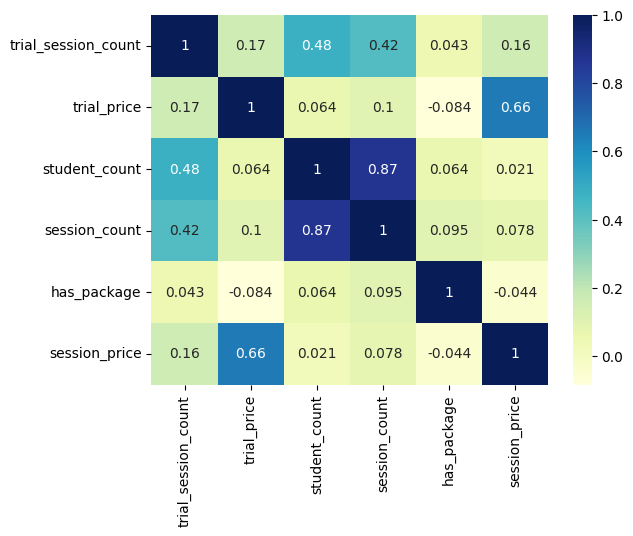

In [122]:
df_model = language_tutor_pro('french', True)
df_model
cor = df_model.corr()

#plot correlation heatmapn
sns.heatmap(cor, cmap="YlGnBu", annot=True)

In [127]:
fig = px.scatter(df_model, x="session_price", y="trial_price", trendline='ols')

# Display the interactive figure
fig.show()